https://www.cs.toronto.edu/~vmnih/data/
https://www.sciencedirect.com/science/article/pii/S2772671123001390


### Pipeline
1. Environment Setup
2. Data Loading & Exploration
3. Model Architectures (U-Net & ResNet-UNet)
4. Data Preprocessing
5. Training Configuration
6. Model Training
7. Evaluation & Metrics Comparison
8. Visualization & Results

## 1. Environment Setup

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import defaultdict
import time
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
from tqdm import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


### Dataset Paths

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Massachusetts Roads/MassachusettsRoadsDataset'
OUTPUT_PATH = '/content/drive/MyDrive/Massachusetts Roads/unet_resnet_comparison'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'results'), exist_ok=True)

## 2. Data Loading & Exploration

In [ ]:
def get_matching_pairs(image_paths, mask_paths):
    image_dict = {Path(p).stem: p for p in image_paths}
    mask_dict = {Path(p).stem: p for p in mask_paths}

    common_names = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    matched_images = [image_dict[name] for name in common_names]
    matched_masks = [mask_dict[name] for name in common_names]

    return matched_images, matched_masks


def load_dataset_paths(base_path):
    data = {}

    for split in ['train', 'valid', 'test']:
        image_pattern = os.path.join(base_path, split, 'input', '*.tif*')
        mask_pattern = os.path.join(base_path, split, 'target', '*.tif*')

        all_images = glob.glob(image_pattern)
        all_masks = glob.glob(mask_pattern)

        matched_images, matched_masks = get_matching_pairs(all_images, all_masks)

        data[split] = {
            'images': matched_images,
            'masks': matched_masks
        }

        print(f" {split.capitalize()}: Found {len(all_images)} images, {len(all_masks)} masks")
        print(f"  Matched pairs: {len(matched_images)}")

        if len(matched_images) != len(all_images) or len(matched_images) != len(all_masks):
            print(f"   Warning: Some files don't have matching pairs!")

    return data

In [ ]:
dataset_paths = load_dataset_paths(DATASET_PATH)

print("\nVerifying data integrity...")
for split in ['train', 'valid', 'test']:
    n_images = len(dataset_paths[split]['images'])
    n_masks = len(dataset_paths[split]['masks'])
    assert n_images == n_masks, f"{split}: Mismatch between images and masks!"
    assert n_images > 0, f"{split}: No data found!"
    print(f"✓ {split.capitalize()}: {n_images} verified pairs")

 Train: Found 1108 images, 1108 masks
  Matched pairs: 1108
 Valid: Found 14 images, 14 masks
  Matched pairs: 14
 Test: Found 49 images, 49 masks
  Matched pairs: 49

Verifying data integrity...
✓ Train: 1108 verified pairs
✓ Valid: 14 verified pairs
✓ Test: 49 verified pairs


## 3. Model Architectures

### U-Net Architecture

(Conv2D => BN => ReLU) * 2

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

Downscaling with maxpool then double conv

In [ ]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

Upscaling then double conv

In [ ]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle odd-sized inputs
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [ ]:
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=2, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

### ResNet-UNet Architecture

U-Net with ResNet34 encoder

In [ ]:
class ResNetUNet(nn.Module):
    def __init__(self, n_classes=2, pretrained=True):
        super(ResNetUNet, self).__init__()

        # Load pretrained ResNet34
        resnet = models.resnet34(pretrained=pretrained)

        # Encoder (ResNet backbone)
        self.encoder1 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )  # 64 channels
        self.encoder2 = nn.Sequential(
            resnet.maxpool,
            resnet.layer1
        )  # 64 channels
        self.encoder3 = resnet.layer2  # 128 channels
        self.encoder4 = resnet.layer3  # 256 channels
        self.encoder5 = resnet.layer4  # 512 channels

        # Decoder
        self.up1 = Up(512 + 256, 256, bilinear=True)
        self.up2 = Up(256 + 128, 128, bilinear=True)
        self.up3 = Up(128 + 64, 64, bilinear=True)
        self.up4 = Up(64 + 64, 64, bilinear=True)

        # Final upsampling and output
        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        # Encoder
        x1 = self.encoder1(x)      # 64 channels
        x2 = self.encoder2(x1)     # 64 channels
        x3 = self.encoder3(x2)     # 128 channels
        x4 = self.encoder4(x3)     # 256 channels
        x5 = self.encoder5(x4)     # 512 channels

        # Decoder with skip connections
        x = self.up1(x5, x4)       # 256 channels
        x = self.up2(x, x3)        # 128 channels
        x = self.up3(x, x2)        # 64 channels
        x = self.up4(x, x1)        # 64 channels
        x = self.final_up(x)       # 64 channels

        logits = self.outc(x)
        return logits

## 4. Data Preprocessing

In [ ]:
class RoadDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, img_size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        mask = Image.open(self.mask_paths[idx]).convert('L')

        # Resize
        image = image.resize(self.img_size, Image.BILINEAR)
        mask = mask.resize(self.img_size, Image.NEAREST)

        # Convert to tensors
        image = transforms.ToTensor()(image)
        mask = torch.from_numpy(np.array(mask)).long()

        # Normalize mask to 0 and 1
        mask = (mask > 0).long()

        # Apply transforms if any
        if self.transform:
            image = self.transform(image)

        return image, mask

Data augmentation for training

In [ ]:
train_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Create datasets

In [ ]:
train_dataset = RoadDataset(
    dataset_paths['train']['images'],
    dataset_paths['train']['masks'],
    transform=train_transform
)

valid_dataset = RoadDataset(
    dataset_paths['valid']['images'],
    dataset_paths['valid']['masks'],
    transform=val_transform
)

test_dataset = RoadDataset(
    dataset_paths['test']['images'],
    dataset_paths['test']['masks'],
    transform=val_transform
)

Create dataloaders

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 139
Valid batches: 2
Test batches: 7


## 5. Training Configuration

Compute segmentation metrics

In [ ]:
def compute_metrics(preds, labels):

    preds = preds.flatten()
    labels = labels.flatten()

    # Filter out ignore index if present
    mask = labels != -100
    preds = preds[mask]
    labels = labels[mask]

    if len(preds) == 0:
        return {'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

    metrics = {
        'iou': float(jaccard_score(labels, preds, average='binary', pos_label=1, zero_division=0)),
        'precision': float(precision_score(labels, preds, average='binary', pos_label=1, zero_division=0)),
        'recall': float(recall_score(labels, preds, average='binary', pos_label=1, zero_division=0)),
        'f1': float(f1_score(labels, preds, average='binary', pos_label=1, zero_division=0))
    }

    return metrics

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Get predictions
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(masks.cpu().numpy())

    avg_loss = total_loss / len(loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_preds, all_labels)

    return avg_loss, metrics

In [ ]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc='Validation'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            # Get predictions
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(masks.cpu().numpy())

    avg_loss = total_loss / len(loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_preds, all_labels)

    return avg_loss, metrics

Train a model and return training history

In [ ]:
def train_model(model, train_loader, valid_loader, epochs, lr, model_name, device):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_iou': [],
        'val_iou': [],
        'train_f1': [],
        'val_f1': []
    }

    best_val_iou = 0
    start_time = time.time()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Training
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validation
        val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)

        # Update learning rate
        scheduler.step(val_metrics['iou'])

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics['iou'])
        history['val_iou'].append(val_metrics['iou'])
        history['train_f1'].append(train_metrics['f1'])
        history['val_f1'].append(val_metrics['f1'])

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
        print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

        # Save best model
        if val_metrics['iou'] > best_val_iou:
            best_val_iou = val_metrics['iou']
            torch.save(model.state_dict(), os.path.join(OUTPUT_PATH, 'checkpoints', f'{model_name}_best.pth'))
            print(f"✓ Saved best model (IoU: {best_val_iou:.4f})")

    training_time = time.time() - start_time
    print(f"\nTotal training time: {training_time:.2f} seconds")

    return history, training_time

## 6. Model Training

### Train U-Net

Initialize U-Net

In [ ]:
unet_model = UNet(n_channels=3, n_classes=2, bilinear=True).to(device)
print(f"U-Net Parameters: {sum(p.numel() for p in unet_model.parameters()):,}")

U-Net Parameters: 17,263,042


In [ ]:
EPOCHS = 20
LEARNING_RATE = 1e-4

print("Training U-Net")
unet_history, unet_time = train_model(
    unet_model,
    train_loader,
    valid_loader,
    EPOCHS,
    LEARNING_RATE,
    'unet',
    device
)

Training U-Net

Epoch 1/20


Validation: 100%|██████████| 2/2 [00:14<00:00,  7.31s/it]


Train Loss: 0.4161 | Val Loss: 0.3313
Train IoU: 0.0395 | Val IoU: 0.0002
Train F1: 0.0760 | Val F1: 0.0004
✓ Saved best model (IoU: 0.0002)

Epoch 2/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.04it/s]


Train Loss: 0.2598 | Val Loss: 0.2544
Train IoU: 0.0005 | Val IoU: 0.0001
Train F1: 0.0009 | Val F1: 0.0002

Epoch 3/20


...

Train Loss: 0.1002 | Val Loss: 0.1249
Train IoU: 0.4257 | Val IoU: 0.4747
Train F1: 0.5972 | Val F1: 0.6438
✓ Saved best model (IoU: 0.4747)

Epoch 19/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.29it/s]


Train Loss: 0.0993 | Val Loss: 0.1163
Train IoU: 0.4307 | Val IoU: 0.4519
Train F1: 0.6021 | Val F1: 0.6224

Epoch 20/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


Train Loss: 0.0975 | Val Loss: 0.1150
Train IoU: 0.4364 | Val IoU: 0.4552
Train F1: 0.6077 | Val F1: 0.6257

Total training time: 3153.53 seconds


adding more training (20 epoch)

In [ ]:
unet_history, unet_time = train_model(
    unet_model,
    train_loader,
    valid_loader,
    EPOCHS,
    LEARNING_RATE,
    'unet',
    device
)


Epoch 1/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.17it/s]


Train Loss: 0.1000 | Val Loss: 0.1177
Train IoU: 0.4244 | Val IoU: 0.4875
Train F1: 0.5959 | Val F1: 0.6555
✓ Saved best model (IoU: 0.4875)

Epoch 2/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.32it/s]


Train Loss: 0.0974 | Val Loss: 0.1160
Train IoU: 0.4349 | Val IoU: 0.4406
Train F1: 0.6062 | Val F1: 0.6117

Epoch 3/20


...

Train Loss: 0.0798 | Val Loss: 0.1059
Train IoU: 0.5137 | Val IoU: 0.5112
Train F1: 0.6787 | Val F1: 0.6765

Epoch 19/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


Train Loss: 0.0786 | Val Loss: 0.1079
Train IoU: 0.5183 | Val IoU: 0.5091
Train F1: 0.6827 | Val F1: 0.6747

Epoch 20/20


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


Train Loss: 0.0762 | Val Loss: 0.1071
Train IoU: 0.5281 | Val IoU: 0.5181
Train F1: 0.6911 | Val F1: 0.6825

Total training time: 2351.49 seconds


### Train ResNet-UNet

 Initialize ResNet-UNet

In [ ]:
resnet_unet_model = ResNetUNet(n_classes=2, pretrained=True).to(device)
print(f"ResNet-UNet Parameters: {sum(p.numel() for p in resnet_unet_model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 209MB/s]


ResNet-UNet Parameters: 26,079,810


In [ ]:
EPOCHS = 40
LEARNING_RATE = 1e-4

In [ ]:
print("Training ResNet-UNet")
resnet_history, resnet_time = train_model(
    resnet_unet_model,
    train_loader,
    valid_loader,
    EPOCHS,
    LEARNING_RATE,
    'resnet_unet',
    device
)

Training ResNet-UNet

Epoch 1/40


Validation: 100%|██████████| 2/2 [00:17<00:00,  8.52s/it]


Train Loss: 0.2761 | Val Loss: 0.2439
Train IoU: 0.0063 | Val IoU: 0.0005
Train F1: 0.0125 | Val F1: 0.0011
✓ Saved best model (IoU: 0.0005)

Epoch 2/40


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


Train Loss: 0.1921 | Val Loss: 0.2148
Train IoU: 0.0006 | Val IoU: 0.0004
Train F1: 0.0012 | Val F1: 0.0009

Epoch 3/40


...

Validation: 100%|██████████| 2/2 [00:01<00:00,  1.70it/s]


Train Loss: 0.0838 | Val Loss: 0.1463
Train IoU: 0.4455 | Val IoU: 0.3625
Train F1: 0.6164 | Val F1: 0.5321

Epoch 28/40


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


Train Loss: 0.0825 | Val Loss: 0.1485
Train IoU: 0.4521 | Val IoU: 0.3523
Train F1: 0.6226 | Val F1: 0.5210

Epoch 29/40


Training: 100%|██████████| 139/139 [01:52<00:00,  1.24it/s]


## 7. Evaluation & Metrics Comparison

Evaluate model on test set

In [ ]:
def evaluate_model(model, test_loader, device, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Testing {model_name}'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(masks.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_preds, all_labels)

    return metrics

Load best models

In [ ]:
unet_model.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, 'checkpoints', 'unet_best.pth')))

In [ ]:
resnet_unet_model.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, 'checkpoints', 'resnet_unet_best.pth')))

Evaluate on test set

In [ ]:
unet_test_metrics = evaluate_model(unet_model, test_loader, device, 'U-Net')
resnet_test_metrics = evaluate_model(resnet_unet_model, test_loader, device, 'ResNet-UNet')

print("\nU-Net:")
print(f"  IoU:       {unet_test_metrics['iou']:.4f}")
print(f"  Precision: {unet_test_metrics['precision']:.4f}")
print(f"  Recall:    {unet_test_metrics['recall']:.4f}")
print(f"  F1 Score:  {unet_test_metrics['f1']:.4f}")

print("\nResNet-UNet:")
print(f"  IoU:       {resnet_test_metrics['iou']:.4f}")
print(f"  Precision: {resnet_test_metrics['precision']:.4f}")
print(f"  Recall:    {resnet_test_metrics['recall']:.4f}")
print(f"  F1 Score:  {resnet_test_metrics['f1']:.4f}")

Testing ResNet-UNet: 100%|██████████| 7/7 [00:03<00:00,  2.11it/s]



U-Net:
  IoU:       0.5572
  Precision: 0.7627
  Recall:    0.6740
  F1 Score:  0.7156

ResNet-UNet:
  IoU:       0.4202
  Precision: 0.6866
  Recall:    0.5200
  F1 Score:  0.5918


Define hyperparameter search space

In [ ]:
hyperparameter_configs = [
    {
        'name': 'baseline',
        'learning_rate': 1e-4,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',  # cross-entropy
    },
    {
        'name': 'higher_lr',
        'learning_rate': 5e-4,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'lower_lr',
        'learning_rate': 5e-5,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'larger_batch',
        'learning_rate': 1e-4,
        'batch_size': 16,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'smaller_batch',
        'learning_rate': 1e-4,
        'batch_size': 4,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'adamw_wd',
        'learning_rate': 1e-4,
        'batch_size': 8,
        'optimizer': 'adamw',
        'weight_decay': 0.01,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'sgd_momentum',
        'learning_rate': 1e-3,
        'batch_size': 8,
        'optimizer': 'sgd',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',
    },
    {
        'name': 'dice_loss',
        'learning_rate': 1e-4,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'dice',
    },
    {
        'name': 'combined_loss',
        'learning_rate': 1e-4,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'combined',  # CE + Dice
    },
    {
        'name': 'best_combo',
        'learning_rate': 1e-4,
        'batch_size': 8,
        'optimizer': 'adamw',
        'weight_decay': 0.01,
        'dropout': 0.1,
        'loss': 'combined',
    },
]

print(f"Total configurations to test: {len(hyperparameter_configs)}")
for i, config in enumerate(hyperparameter_configs):
    print(f"{i+1}. {config['name']}: LR={config['learning_rate']}, BS={config['batch_size']}, "
          f"Opt={config['optimizer']}, Loss={config['loss']}")

Total configurations to test: 10
1. baseline: LR=0.0001, BS=8, Opt=adam, Loss=ce
2. higher_lr: LR=0.0005, BS=8, Opt=adam, Loss=ce
3. lower_lr: LR=5e-05, BS=8, Opt=adam, Loss=ce
4. larger_batch: LR=0.0001, BS=16, Opt=adam, Loss=ce
5. smaller_batch: LR=0.0001, BS=4, Opt=adam, Loss=ce
6. adamw_wd: LR=0.0001, BS=8, Opt=adamw, Loss=ce
7. sgd_momentum: LR=0.001, BS=8, Opt=sgd, Loss=ce
8. dice_loss: LR=0.0001, BS=8, Opt=adam, Loss=dice
9. combined_loss: LR=0.0001, BS=8, Opt=adam, Loss=combined
10. best_combo: LR=0.0001, BS=8, Opt=adamw, Loss=combined


Dice loss for segmentation

In [ ]:
def dice_loss(pred, target, smooth=1.0):

    pred = torch.softmax(pred, dim=1)[:, 1]  # Get road class probabilities
    pred_flat = pred.view(-1)
    target_flat = target.view(-1).float()

    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
    return 1 - dice

Combination of Cross-Entropy and Dice loss

In [ ]:
def combined_loss(pred, target, alpha=0.5):

    ce = nn.CrossEntropyLoss()(pred, target)
    dice = dice_loss(pred, target)
    return alpha * ce + (1 - alpha) * dice

Get loss function based on type

In [ ]:
def get_loss_function(loss_type):

    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'dice':
        return dice_loss
    elif loss_type == 'combined':
        return combined_loss
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

Train model with specific hyperparameter configuration

In [ ]:
def train_model_with_config(model, train_dataset, valid_dataset, config, epochs, model_name, device):

    # Create dataloaders with config batch size
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=0
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=0
    )

    # Get loss function
    criterion = get_loss_function(config['loss'])

    # Get optimizer
    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['learning_rate'],
            weight_decay=config['weight_decay']
        )
    elif config['optimizer'] == 'adamw':
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['learning_rate'],
            weight_decay=config['weight_decay']
        )
    elif config['optimizer'] == 'sgd':
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config['learning_rate'],
            momentum=0.9,
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_iou': [],
        'val_iou': [],
        'train_f1': [],
        'val_f1': []
    }

    best_val_iou = 0
    start_time = time.time()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Training
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validation
        val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)

        # Update learning rate
        scheduler.step(val_metrics['iou'])

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics['iou'])
        history['val_iou'].append(val_metrics['iou'])
        history['train_f1'].append(train_metrics['f1'])
        history['val_f1'].append(val_metrics['f1'])

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
        print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

        # Save best model
        if val_metrics['iou'] > best_val_iou:
            best_val_iou = val_metrics['iou']
            save_path = os.path.join(
                OUTPUT_PATH,
                'checkpoints',
                f'{model_name}_{config["name"]}_best.pth'
            )
            torch.save(model.state_dict(), save_path)
            print(f"✓ Saved best model (IoU: {best_val_iou:.4f})")

    training_time = time.time() - start_time

    return history, training_time, best_val_iou

U-NET

In [ ]:
TUNING_EPOCHS = 10
unet_tuning_results = []

for i, config in enumerate(hyperparameter_configs):
    print(f"\n{'-'*60}")
    print(f"Configuration {i+1}/{len(hyperparameter_configs)}: {config['name']}")
    print(f"{'='*60}")
    print(f"LR: {config['learning_rate']}, BS: {config['batch_size']}, "
          f"Opt: {config['optimizer']}, Loss: {config['loss']}")

    # Initialize fresh model
    model = UNet(n_channels=3, n_classes=2, bilinear=True).to(device)

    # Train with this config
    history, train_time, best_iou = train_model_with_config(
        model,
        train_dataset,
        valid_dataset,
        config,
        TUNING_EPOCHS,
        'unet',
        device
    )

    # Store results
    result = {
        'config_name': config['name'],
        'config': config,
        'best_val_iou': best_iou,
        'best_val_f1': max(history['val_f1']),
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'training_time': train_time,
        'history': history
    }
    unet_tuning_results.append(result)

    print(f"\n✓ Config '{config['name']}' completed:")
    print(f"  Best Val IoU: {best_iou:.4f}")
    print(f"  Best Val F1: {max(history['val_f1']):.4f}")
    print(f"  Training time: {train_time:.2f}s")

    # Clean up memory
    del model
    torch.cuda.empty_cache()


------------------------------------------------------------
Configuration 1/10: baseline
LR: 0.0001, BS: 8, Opt: adam, Loss: ce

Epoch 1/10


Validation: 100%|██████████| 2/2 [00:21<00:00, 10.70s/it]


Train Loss: 0.4080 | Val Loss: 0.3354
Train IoU: 0.0406 | Val IoU: 0.0000
Train F1: 0.0780 | Val F1: 0.0000

Epoch 2/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.54it/s]


Train Loss: 0.2581 | Val Loss: 0.2666
Train IoU: 0.0003 | Val IoU: 0.0000
Train F1: 0.0005 | Val F1: 0.0000

Epoch 3/10


...

Validation: 100%|██████████| 4/4 [00:01<00:00,  3.24it/s]


Train Loss: 0.1749 | Val Loss: 0.1844
Train IoU: 0.0504 | Val IoU: 0.1499
Train F1: 0.0959 | Val F1: 0.2607
✓ Saved best model (IoU: 0.1499)

Epoch 3/10


Validation: 100%|██████████| 4/4 [00:01<00:00,  3.28it/s]


Train Loss: 0.1434 | Val Loss: 0.1598
Train IoU: 0.1855 | Val IoU: 0.2646
Train F1: 0.3129 | Val F1: 0.4185
✓ Saved best model (IoU: 0.2646)

Epoch 4/10


Training:  93%|█████████▎| 258/277 [02:05<00:09,  2.08it/s]

In [ ]:
TUNING_EPOCHS = 10
unet_tuning_results = []

for i, config in enumerate(hyperparameter_configs):
    print(f"\n{'-'*60}")
    print(f"Configuration {i+1}/{len(hyperparameter_configs)}: {config['name']}")
    print(f"{'-'*60}")
    print(f"LR: {config['learning_rate']}, BS: {config['batch_size']}, "
          f"Opt: {config['optimizer']}, Loss: {config['loss']}")

    # Initialize fresh model
    model = UNet(n_channels=3, n_classes=2, bilinear=True).to(device)

    # Train with this config
    history, train_time, best_iou = train_model_with_config(
        model,
        train_dataset,
        valid_dataset,
        config,
        TUNING_EPOCHS,
        'unet',
        device
    )

    # Store results
    result = {
        'config_name': config['name'],
        'config': config,
        'best_val_iou': best_iou,
        'best_val_f1': max(history['val_f1']),
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'training_time': train_time,
        'history': history
    }
    unet_tuning_results.append(result)

    print(f"\n✓ Config '{config['name']}' completed:")
    print(f"  Best Val IoU: {best_iou:.4f}")
    print(f"  Best Val F1: {max(history['val_f1']):.4f}")
    print(f"  Training time: {train_time:.2f}s")

    # Clean up memory
    del model
    torch.cuda.empty_cache()


------------------------------------------------------------
Configuration 1/5: adamw_wd
------------------------------------------------------------
LR: 0.0001, BS: 8, Opt: adamw, Loss: ce

Epoch 1/10


Validation: 100%|██████████| 2/2 [00:16<00:00,  8.47s/it]


Train Loss: 0.3966 | Val Loss: 0.3144
Train IoU: 0.0359 | Val IoU: 0.0000
Train F1: 0.0693 | Val F1: 0.0000
✓ Saved best model (IoU: 0.0000)

Epoch 2/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.68it/s]


Train Loss: 0.2546 | Val Loss: 0.2652
Train IoU: 0.0002 | Val IoU: 0.0000
Train F1: 0.0004 | Val F1: 0.0000

Epoch 3/10


...

Train Loss: 0.1400 | Val Loss: 0.1769
Train IoU: 0.0654 | Val IoU: 0.0944
Train F1: 0.1227 | Val F1: 0.1724
✓ Saved best model (IoU: 0.0944)

Epoch 10/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s]


Train Loss: 0.1380 | Val Loss: 0.1738
Train IoU: 0.0887 | Val IoU: 0.1336
Train F1: 0.1629 | Val F1: 0.2357
✓ Saved best model (IoU: 0.1336)

✓ Config 'sgd_momentum' completed:
  Best Val IoU: 0.1336
  Best Val F1: 0.2357
  Training time: 1619.54s

------------------------------------------------------------
Configuration 3/5: dice_loss
------------------------------------------------------------
LR: 0.0001, BS: 8, Opt: adam, Loss: dice

Epoch 1/10


Training:   0%|          | 0/139 [00:00<?, ?it/s]


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

Find best configuration

In [ ]:
best_config = max(unet_tuning_results, key=lambda x: x['best_val_iou'])
print(f"\n Best U-Net Configuration: {best_config['config_name']}")
print(f"   Val IoU: {best_config['best_val_iou']:.4f}")
print(f"   Val F1: {best_config['best_val_f1']:.4f}")
print(f"   Config: {best_config['config']}")


 Best U-Net Configuration: adamw_wd
   Val IoU: 0.3726
   Val F1: 0.5429
   Config: {'name': 'adamw_wd', 'learning_rate': 0.0001, 'batch_size': 8, 'optimizer': 'adamw', 'weight_decay': 0.01, 'dropout': 0.0, 'loss': 'ce'}


Best U-Net Configuration :     

        'name': 'higher_lr',
        'learning_rate': 5e-4,
        'batch_size': 8,
        'optimizer': 'adam',
        'weight_decay': 0.0,
        'dropout': 0.0,
        'loss': 'ce',

          Best Val IoU: 0.4884
          Best Val F1: 0.6563
          Training time: 1638.37s


Configuration

In [ ]:
CHECKPOINT_PATH = '/content/drive/MyDrive/Massachusetts Roads/unet_resnet_comparison/checkpoints/unet_higher_lr_best.pth'
CONTINUE_EPOCHS = 10
LEARNING_RATE = 2e-5
BATCH_SIZE = 8

Loading model

In [ ]:
model = UNet(n_channels=3, n_classes=2, bilinear=True).to(device)
model.load_state_dict(torch.load(CHECKPOINT_PATH))

<All keys matched successfully>

Initial evaluation

In [ ]:
model.eval()
criterion = nn.CrossEntropyLoss()
val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)
print(f"\nInitial performance:")
print(f"  Val IoU: {val_metrics['iou']:.4f}")
print(f"  Val F1:  {val_metrics['f1']:.4f}")

Validation: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]


Initial performance:
  Val IoU: 0.4884
  Val F1:  0.6563


Optimizer and scheduler

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_iou': [],
    'val_iou': [],
    'train_f1': [],
    'val_f1': []
}

best_val_iou = val_metrics['iou']
print(f"Starting IoU to beat: {best_val_iou:.4f}")

Starting IoU to beat: 0.4884


In [ ]:
print(f"\Training for {CONTINUE_EPOCHS} epochs...")
start_time = time.time()

for epoch in range(CONTINUE_EPOCHS):
    print(f"\nEpoch {epoch+1}/{CONTINUE_EPOCHS}")

    # Train
    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_metrics['iou'])

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_metrics['iou'])
    history['val_iou'].append(val_metrics['iou'])
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])

    # Print metrics
    print(f"Loss:  Train={train_loss:.4f}  Val={val_loss:.4f}")
    print(f"IoU:   Train={train_metrics['iou']:.4f}  Val={val_metrics['iou']:.4f}")
    print(f"F1:    Train={train_metrics['f1']:.4f}  Val={val_metrics['f1']:.4f}")

    # Save if improved
    if val_metrics['iou'] > best_val_iou:
        best_val_iou = val_metrics['iou']
        save_path = os.path.join(OUTPUT_PATH, 'checkpoints', 'unet_continued_best.pth')
        torch.save(model.state_dict(), save_path)
        print(f"✓ New best model saved (IoU: {best_val_iou:.4f})")

training_time = time.time() - start_time


print("TRAINING COMPLETE")
print(f"Time: {training_time:.2f}s ({training_time/60:.1f} min)")
print(f"Best Val IoU: {best_val_iou:.4f}")
print(f"Improvement: {best_val_iou - val_metrics['iou']:.4f}")


<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipython-input-300674426.py:1: SyntaxWarning: invalid escape sequence '\T'
  print(f"\Training for {CONTINUE_EPOCHS} epochs...")


\Training for 10 epochs...

Epoch 1/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.53it/s]


Loss:  Train=0.0927  Val=0.1078
IoU:   Train=0.4575  Val=0.4924
F1:    Train=0.6278  Val=0.6599
✓ New best model saved (IoU: 0.4924)

Epoch 2/10


Validation: 100%|██████████| 2/2 [00:00<00:00,  2.13it/s]


...

Loss:  Train=0.0896  Val=0.1057
IoU:   Train=0.4691  Val=0.4998
F1:    Train=0.6386  Val=0.6665

Epoch 9/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.68it/s]


Loss:  Train=0.0896  Val=0.1053
IoU:   Train=0.4694  Val=0.5057
F1:    Train=0.6389  Val=0.6717
✓ New best model saved (IoU: 0.5057)

Epoch 10/10


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]

Loss:  Train=0.0898  Val=0.1053
IoU:   Train=0.4716  Val=0.5030
F1:    Train=0.6409  Val=0.6693
TRAINING COMPLETE
Time: 1644.20s (27.4 min)
Best Val IoU: 0.5057
Improvement: 0.0027


Evaluating on test set

In [ ]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, 'checkpoints', 'unet_continued_best.pth')))
model.eval()

all_preds = []
all_labels = []

In [ ]:
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(masks.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
test_metrics = compute_metrics(all_preds, all_labels)

print(f"IoU:       {test_metrics['iou']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1 Score:  {test_metrics['f1']:.4f}")

Testing: 100%|██████████| 7/7 [01:00<00:00,  8.70s/it]


IoU:       0.5467
Precision: 0.7918
Recall:    0.6384
F1 Score:  0.7069


## 8. prediction visualizations

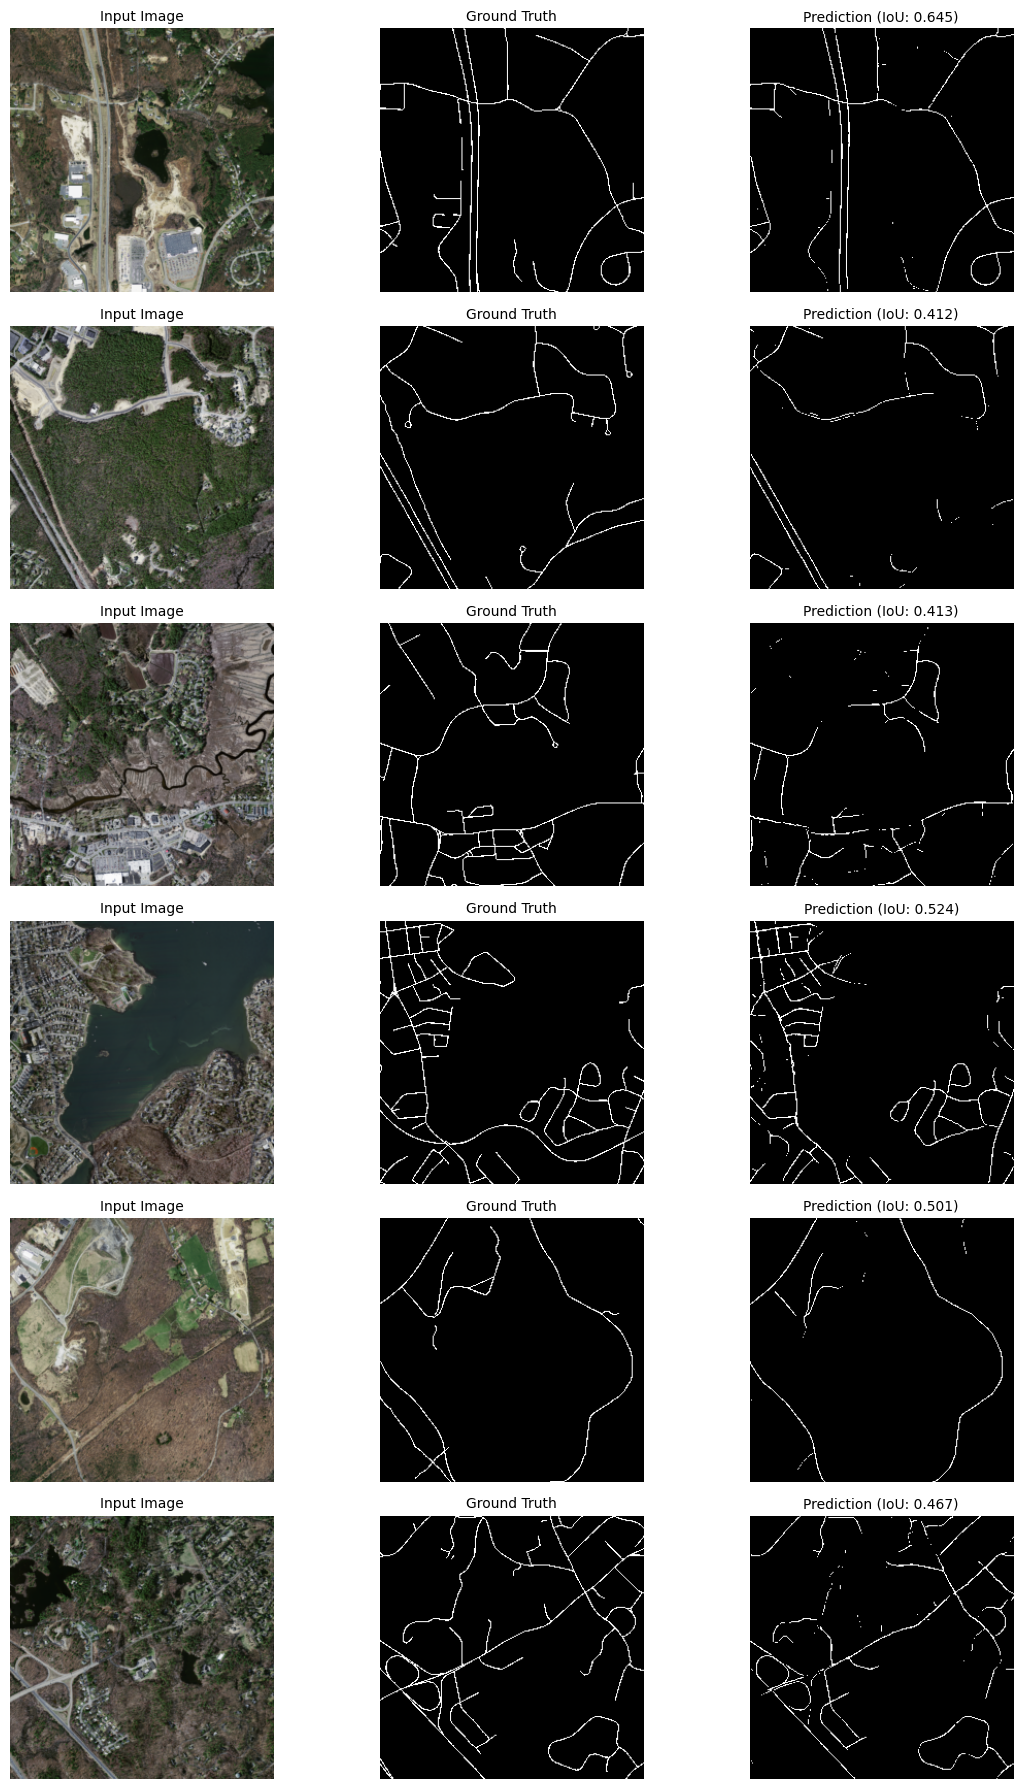

In [ ]:
num_samples = 6
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3*num_samples))

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):

        image, mask = test_dataset[idx]
        image_input = image.unsqueeze(0).to(device)

        # Predict
        output = model(image_input)
        pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()

        # Denormalize image
        img_display = image.cpu().numpy().transpose(1, 2, 0)
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        # Compute IoU for this sample
        sample_iou = jaccard_score(mask.flatten(), pred.flatten(), average='binary', zero_division=0)

        # Plot
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title('Input Image', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f'Prediction (IoU: {sample_iou:.3f})', fontsize=10)
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'results', 'test_predictions.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## confusion matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
from tqdm import tqdm

Collecting predictions on test set

In [ ]:
model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Processing'):
        images = images.to(device)
        masks = masks.to(device)

        # Get predictions
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        # Store flattened predictions and ground truth
        all_predictions.append(predictions.cpu().numpy().flatten())
        all_ground_truth.append(masks.cpu().numpy().flatten())

# Concatenate all batches
y_true = np.concatenate(all_ground_truth)
y_pred = np.concatenate(all_predictions)

print(f"✓ Total pixels analyzed: {len(y_true):,}")
print(f"  Background pixels: {np.sum(y_true == 0):,} ({100 * np.sum(y_true == 0) / len(y_true):.1f}%)")
print(f"  Road pixels:       {np.sum(y_true == 1):,} ({100 * np.sum(y_true == 1) / len(y_true):.1f}%)")

Processing: 100%|██████████| 7/7 [00:03<00:00,  1.86it/s]

✓ Total pixels analyzed: 3,211,264
  Background pixels: 3,060,450 (95.3%)
  Road pixels:       150,814 (4.7%)


Computing confusion matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

# Normalize confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nConfusion Matrix (Raw Counts):")
print(cm)
print("\nConfusion Matrix (Normalized):")
print(cm_normalized)

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\nClassification Breakdown:")
print(f"  True Negatives  (TN): {tn:,} - Correctly identified background")
print(f"  False Positives (FP): {fp:,} - Background misclassified as road")
print(f"  False Negatives (FN): {fn:,} - Road misclassified as background")
print(f"  True Positives  (TP): {tp:,} - Correctly identified road")


Confusion Matrix (Raw Counts):
[[3035128   25322]
 [  54528   96286]]

Confusion Matrix (Normalized):
[[0.99172605 0.00827395]
 [0.36155795 0.63844205]]

Classification Breakdown:
  True Negatives  (TN): 3,035,128 - Correctly identified background
  False Positives (FP): 25,322 - Background misclassified as road
  False Negatives (FN): 54,528 - Road misclassified as background
  True Positives  (TP): 96,286 - Correctly identified road


Creating visualizations

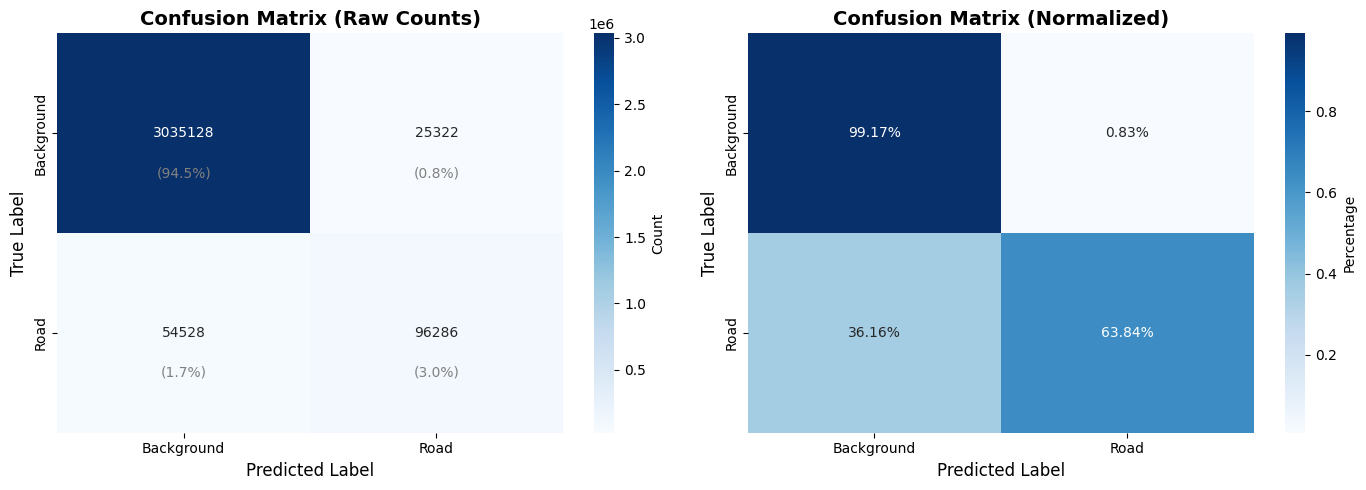

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = ['Background', 'Road']

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

# Add text annotations with percentages
for i in range(2):
    for j in range(2):
        percentage = 100 * cm[i, j] / cm.sum()
        axes[0].text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=10, color='gray')

# Plot 2: Normalized (percentages)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'results', 'confusion_matrix.png'),
            dpi=300, bbox_inches='tight')
plt.show()